## Tomato Pollination: Tomato 2

In [1]:
import numpy as np
import dismech
import os

plant_name = "tomato2"

position = "1"

geom = dismech.GeomParams(
    rod_r0=0.03,
    shell_h=0.0,
)

material = dismech.Material(density=1100,
                            youngs_rod=2.16e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dyn_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=50,
                                  total_time=5,
                                  plot_step=10,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2
                                  )

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=100)

input_txt = os.path.join('../tests/resources/tomato_pollination/plants/', f"{plant_name}.txt")
geo = dismech.Geometry.from_txt(input_txt)

robot = dismech.SoftRobot(geom, material, geo, dyn_sim, env)

### Move the stem: Moving BC

In [2]:
# # --- pick the main grip node robustly ---
# grasping_point = np.array([
#       1.1154284,
#       0.0092739,
#       0.4896594
#     ])
# xyz = robot.state.q[robot.node_dof_indices].reshape(-1, 3)

main_grip = 15  # node at the main grip

print("Main grip node:", main_grip)

other_grip_nodes_below = np.array(range(main_grip-4, main_grip), dtype=int)
other_grip_nodes_above = np.arange(main_grip+4, main_grip, -1, dtype=int)

print("Other grip nodes below:", other_grip_nodes_below)
print("Other grip nodes above:", other_grip_nodes_above)

Main grip node: 15
Other grip nodes below: [11 12 13 14]
Other grip nodes above: [19 18 17 16]


In [3]:
base_nodes = np.where((robot.state.q[robot.node_dof_indices].reshape(-1, 3)[:, 2]) < 0.22)[0] # fixed base
# Fix only main_grip and base nodes
robot = robot.fix_nodes(np.unique(np.r_[main_grip, base_nodes]))

In [4]:
# ----- once, before simulation -----

all_grip_nodes = np.r_[main_grip, other_grip_nodes_below, other_grip_nodes_above].astype(int)

xyz0 = robot.state.q[robot.node_dof_indices].reshape(-1, 3).copy()
x0 = xyz0[all_grip_nodes, 0].copy()          # initial x of all prescribed nodes
prev_target_x = x0.copy()                     # last absolute target (starts at initial)

# (Optional) precompute amplitude scalings from *initial* geometry
def build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main):
    amps = np.empty(all_grip_nodes.size, float)
    amps[0] = A_main  # main_grip
    # below group
    below = np.array(other_grip_nodes_below, dtype=int)
    if below.size:
        ref = below[0]
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(below, start=1):  # start=1 because 0 is main_grip
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    # above group
    above = np.array(other_grip_nodes_above, dtype=int)
    if above.size:
        ref = above[0]
        offset = 1 + below.size
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(above, start=offset):
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    return amps

A_main = 0.340670063e-2   # m at main_grip
freq   = 1.3    # Hz
amps   = build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main)

def shake_distributed(robot, t: float):
    # absolute target centered at initial pose
    target_x = x0 + amps * np.sin(2*np.pi*freq*t)

    # INCREMENT ONLY: avoids velocity spikes and keeps symmetry
    delta_x = target_x - prev_target_x
    prev_target_x[:] = target_x

    return robot.move_nodes(all_grip_nodes, delta_x.reshape(-1,1).flatten(), axis=0)

print("grasping points:", all_grip_nodes)

grasping points: [15 11 12 13 14 19 18 17 16]


In [5]:
stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = shake_distributed

### Simulate

In [6]:
# simulate
robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 7428.246
iter: 2, error: 87.001
current_time:  0.01
iter: 1, error: 7379.878
iter: 2, error: 66.725
current_time:  0.02
iter: 1, error: 7281.311
iter: 2, error: 56.741
current_time:  0.03
iter: 1, error: 7134.278
iter: 2, error: 56.764
current_time:  0.04
iter: 1, error: 6940.942
iter: 2, error: 56.157
current_time:  0.05
iter: 1, error: 6702.401
iter: 2, error: 54.272
current_time:  0.06
iter: 1, error: 6419.687
iter: 2, error: 51.232
current_time:  0.07
iter: 1, error: 6094.184
iter: 2, error: 47.026
current_time:  0.08
iter: 1, error: 5727.668
iter: 2, error: 41.673
current_time:  0.09
iter: 1, error: 5322.300
iter: 2, error: 35.541
current_time:  0.1
iter: 1, error: 4880.635
iter: 2, error: 29.201
current_time:  0.11
iter: 1, error: 4405.594
iter: 2, error: 23.145
current_time:  0.12
iter: 1, error: 3900.430
iter: 2, error: 17.656
current_time:  0.13
iter: 1, error: 3368.659
iter: 2, error: 12.852
current_time:  0.14
iter: 1, error: 2814.008
iter: 2, error: 8.781
cu

### Plotting

In [7]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Tomato2', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t, qs , options)
fig.show()

In [8]:
# save gif
# ani = dismech.get_animation(robot, t, qs, options)
# save_path = os.path.join("tomato_results", f"{plant_name}_{position}.gif")
# ani.save(save_path)


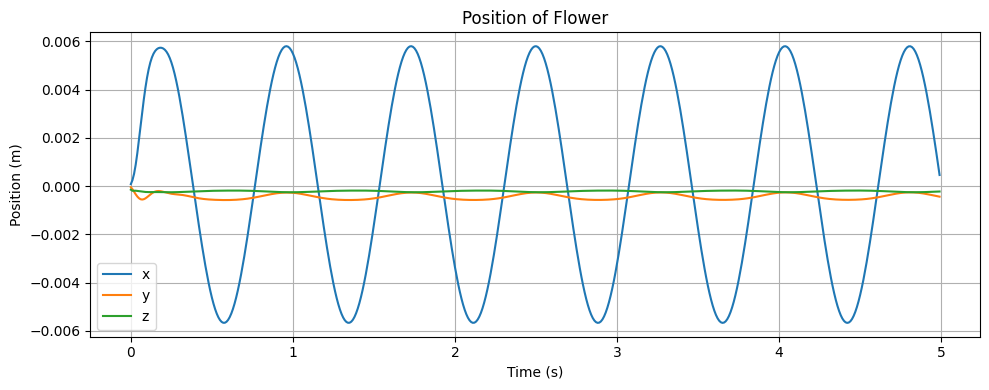

In [9]:
# plot the trajectory of the flower location
flower_node = 73  # pick a node at the flower

import matplotlib.pyplot as plt

# Extract the DOF indices (x, y, z) of the node you want to track
flower_node_dofs = robot.map_node_to_dof(flower_node)  # e.g., [ix, iy, iz]

# Extract position of that node across all timesteps
logged = qs[:, flower_node_dofs].squeeze()  # shape (n_timesteps, 3)

# remove value at t=0
logged -= robot.nodes[flower_node]

# Plot x, y, z over time
t = np.arange(qs.shape[0]) * robot.sim_params.dt

plt.figure(figsize=(10, 4))
plt.plot(t, logged[:, 0], label='x')
plt.plot(t, logged[:, 1], label='y')
plt.plot(t, logged[:, 2], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title(f'Position of Flower')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Save data for rendering

In [10]:
# from dismech.logging import logDataForRendering
# from dismech.logging import export_parachute_data

# rod_data, shell_data = logDataForRendering(qs, t.reshape(-1, 1), robot, len(t), robot.sim_params.static_sim, robot.map_node_to_dof)

# js_file = os.path.join("tomato_results", f"{plant_name}_{position}.js")
# export_parachute_data(qs, geo.rod_edges, robot,
#                           rod_js=js_file,
#                           scaleFactor=100)

In [11]:
import numpy as np
from scipy.signal import hilbert, detrend, find_peaks

def avg_cycle_amplitude_hilbert(x: np.ndarray) -> float:
    """
    Robust average oscillation amplitude using the analytic-signal envelope.
    Returns the median envelope value (less sensitive to outliers).
    """
    x = np.asarray(x).ravel()
    x = detrend(x)  # remove slow drift
    envelope = np.abs(hilbert(x))
    # Use median to resist occasional spikes; mean is also fine.
    return float(np.median(envelope))

In [12]:
# amplitude of flower node motion
amp_x_flower_hilbert = avg_cycle_amplitude_hilbert(logged[:, 0]) # hilbert-based amplitude
amp_x_flower_peak = (np.max(logged[:, 0]) - np.min(logged[:, 0])) / 2.0 # peak-to-peak amplitude
print(f"Amplitude of flower node {flower_node} motion in x (peak-to-peak): {amp_x_flower_peak:.4f} m")
print(f"Amplitude of flower node {flower_node} motion in x (hilbert): {amp_x_flower_hilbert:.4f} m")

Amplitude of flower node 73 motion in x (peak-to-peak): 0.0057 m
Amplitude of flower node 73 motion in x (hilbert): 0.0058 m


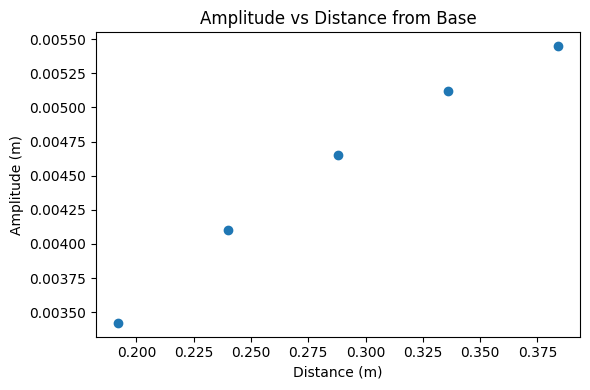

amplitudes: [0.0034212913928413887, 0.0041053393385858125, 0.004651362539847213, 0.005117848652240744, 0.005448884285312277]


In [13]:
# plot the amplitudes of the above nodes in a plot against the distance of the node's z-coordinate from the highest base_node
# get the z-coordinate of the highest base node
nodes_to_plot = [15, 21, 27, 33, 39]
# nodes_to_plot = np.arange(0, 50, 2)  # every 2nd node from 0 to 49
base_node_z = robot.state.q[robot.node_dof_indices].reshape(-1, 3)[base_nodes, 2]
highest_base_node_z = np.max(base_node_z)
distances = []
amplitudes = []
for node in nodes_to_plot:
    node_dofs = robot.map_node_to_dof(node)
    node_z = robot.state.q[node_dofs[2]]
    distance = node_z - highest_base_node_z
    distances.append(distance)
    node_x = qs[:, node_dofs[0]].squeeze()  # x-coordinate
    # amplitude = (node_x.max() - node_x.min()) / 2
    amplitude = avg_cycle_amplitude_hilbert(node_x)     # averaged over time amplitude
    amplitudes.append(amplitude)    
plt.figure(figsize=(6, 4))
plt.scatter(distances, amplitudes)
plt.xlabel('Distance (m)')
plt.ylabel('Amplitude (m)')
plt.title('Amplitude vs Distance from Base')
# plt.grid(True)
plt.tight_layout()
plt.show()
print("amplitudes:", amplitudes)

In [14]:
print(distances)

[np.float64(0.192), np.float64(0.24), np.float64(0.28799990000000003), np.float64(0.336), np.float64(0.38399999999999995)]


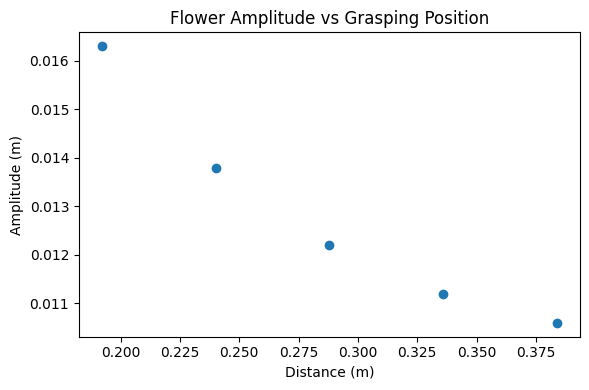

amplitudes: [0.0163, 0.0138, 0.0122, 0.0112, 0.0106]


In [15]:
# plot flower amplitude vs grasping point location
grasping_pos= [15, 21, 27, 33, 39]
base_node_z = robot.state.q[robot.node_dof_indices].reshape(-1, 3)[base_nodes, 2]
highest_base_node_z = np.max(base_node_z)
distances = []
flower_amplitudes = [ 0.0163,
0.0138,
0.0122,
0.0112,
0.0106
]  # from previous runs
for node in grasping_pos:
    node_dofs = robot.map_node_to_dof(node)
    node_z = robot.state.q[node_dofs[2]]
    distance = node_z - highest_base_node_z
    distances.append(distance)
plt.figure(figsize=(6, 4))
plt.scatter(distances, flower_amplitudes)
plt.xlabel('Distance (m)')
plt.ylabel('Amplitude (m)')
plt.title('Flower Amplitude vs Grasping Position')
# plt.grid(True)
plt.tight_layout()
plt.show()
print("amplitudes:", flower_amplitudes)

#### Estimate frequency

In [16]:
# import numpy as np

# def _parabolic_interpolation(y, k):
#     """
#     Fit a parabola through points (k-1, y[k-1]), (k, y[k]), (k+1, y[k+1])
#     and return the sub-bin offset p in [-0.5, 0.5] (approximately).
#     """
#     if k <= 0 or k >= len(y) - 1:
#         return 0.0
#     alpha, beta, gamma = y[k-1], y[k], y[k+1]
#     denom = (alpha - 2*beta + gamma)
#     if denom == 0:
#         return 0.0
#     return 0.5 * (alpha - gamma) / denom

# def estimate_frequency_fft(signal, dt, min_freq=0.0, max_freq=None, pad_factor=8):
#     """
#     Dominant-frequency estimator using:
#       - mean removal
#       - Hann window
#       - zero padding
#       - parabolic interpolation around the spectral peak (log-magnitude)
#     Works well for fractional-bin frequencies.

#     Parameters
#     ----------
#     signal : (N,) array
#     dt     : float, sampling interval (s)
#     min_freq, max_freq : optional band-limit for the search (Hz)
#     pad_factor : int >= 1, zero-padding multiplier

#     Returns
#     -------
#     f_hat : float (Hz)
#     """
#     x = np.asarray(signal, dtype=float)
#     x = x - np.mean(x)
#     N = len(x)
#     fs = 1.0 / dt

#     # Window to reduce leakage
#     w = np.hanning(N)
#     xw = x * w

#     # Zero pad to improve bin resolution
#     Npad = int(2 ** np.ceil(np.log2(max(N, 16)))) * max(1, int(pad_factor))
#     X = np.fft.rfft(xw, n=Npad)
#     freqs = np.fft.rfftfreq(Npad, d=dt)

#     # Limit search band
#     lo = 1  # skip DC by default
#     hi = len(freqs) - 1
#     if min_freq is not None:
#         lo = max(lo, int(np.ceil(min_freq * Npad / fs)))
#     if max_freq is not None:
#         hi = min(hi, int(np.floor(max_freq * Npad / fs)))

#     if hi <= lo:
#         raise ValueError("Invalid min_freq/max_freq band for the given data length.")

#     # Use log-magnitude for more stable interpolation
#     mag_log = np.log(np.abs(X[lo:hi+1])**2 + 1e-30)

#     # Peak bin in the restricted band
#     k_rel = int(np.argmax(mag_log))
#     k = lo + k_rel

#     # Parabolic interpolation around the peak
#     p = _parabolic_interpolation(mag_log, k - lo)  # offset within the sliced array
#     f_hat = (k + p) * fs / Npad
#     return f_hat

# def estimate_frequency_autocorr(signal, dt, min_freq=0.0, max_freq=None):
#     """
#     Dominant-frequency via autocorrelation peak with parabolic interpolation.
#     Good cross-check to FFT; resilient to mild non-sinusoidal waveforms.

#     Parameters
#     ----------
#     signal : (N,) array
#     dt     : float, sampling interval (s)
#     min_freq, max_freq : optional search band (Hz)

#     Returns
#     -------
#     f_hat : float (Hz)
#     """
#     x = np.asarray(signal, dtype=float)
#     x = x - np.mean(x)
#     N = len(x)
#     fs = 1.0 / dt

#     # Full autocorr then keep non-negative lags
#     acf = np.correlate(x, x, mode='full')[N-1:]
#     # Optional normalization improves numerical stability
#     acf = acf / (np.arange(N, 0, -1))

#     # Determine lag search window from freq band
#     lag_min = 1 if (min_freq is None or min_freq <= 0) else int(np.floor(fs / max_freq)) if max_freq else 1
#     lag_max = N-2
#     if min_freq and min_freq > 0:
#         lag_max = min(lag_max, int(np.ceil(fs / min_freq)))

#     if lag_max <= lag_min + 1:
#         raise ValueError("Signal too short for the requested frequency band.")

#     # Peak of ACF in that lag range
#     k = lag_min + int(np.argmax(acf[lag_min:lag_max+1]))

#     # Parabolic interpolation around k (in ACF domain)
#     p = _parabolic_interpolation(acf, k)
#     period = (k + p) / fs
#     if period <= 0:
#         raise ValueError("Autocorr-based period estimate invalid (non-positive).")
#     return 1.0 / period

# def estimate_frequency(signal, dt, method="fft", **kwargs):
#     """
#     Wrapper: method in {"fft", "acf"}.
#     kwargs passed to the chosen estimator.
#     """
#     if method == "fft":
#         return estimate_frequency_fft(signal, dt, **kwargs)
#     elif method == "acf":
#         return estimate_frequency_autocorr(signal, dt, **kwargs)
#     else:
#         raise ValueError("method must be 'fft' or 'acf'")


In [17]:
# f_fft = estimate_frequency(logged[:, 0], robot.sim_params.dt, method="fft", min_freq=0.5, max_freq=40, pad_factor=16)
# print(f"FFT estimator:  {f_fft:.4f} Hz")

#### Time domain frequency calculation